## Set up data and model objects


In [1]:
import pandas as pd
import numpy as np
import mudata as md
from perturbo import run_svi, run_mcmc, perturbseq_guide_turbo, perturbseq_model_turbo
import seaborn as sns
import matplotlib.pyplot as plt
import jax.numpy as jnp


def perturbseq_guide_autonormal(init_loc_fn=init_to_median):
    return AutoNormal(
        perturbseq_model,
        init_loc_fn=init_loc_fn,
        create_plates=_create_plates,
    )


smoke_test = True  # only use selected genes
# smoke_test=False # run full analysis

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


Set training configuration and access to data


### Load the data

(50k cells, takes ~30 seconds)


In [2]:
data_dir = "../../../../Data/gasperini_pilot"

mdata = md.read_h5mu(f"{data_dir}/gasperini_pilot_highMOI.h5mu")
# batch_size=None
mdata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [3]:
mdata["grna"]

AnnData object with n_obs × n_vars = 47964 × 3115
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

In [4]:
element = "ACTB_TSS"
# element = "ACTG1_TSS"

element_guides = mdata["grna"].varm["element_targeted"][element]
element_guides

ACTB_TSS|1       1.0
ACTB_TSS|2       1.0
ACTG1_TSS|1      0.0
ACTG1_TSS|2      0.0
ACYP1_TSS|1      0.0
                ... 
scrambled_7|2    0.0
scrambled_8|1    0.0
scrambled_8|2    0.0
scrambled_9|1    0.0
scrambled_9|2    0.0
Name: ACTB_TSS, Length: 3115, dtype: float32

In [5]:
control_guides = pd.Series(np.zeros(len(element_guides)), index=element_guides.index)
control_guides[-50:] = 1
control_guides

ACTB_TSS|1       0.0
ACTB_TSS|2       0.0
ACTG1_TSS|1      0.0
ACTG1_TSS|2      0.0
ACYP1_TSS|1      0.0
                ... 
scrambled_7|2    1.0
scrambled_8|1    1.0
scrambled_8|2    1.0
scrambled_9|1    1.0
scrambled_9|2    1.0
Length: 3115, dtype: float64

In [6]:
selected_guides = element_guides + control_guides
selected_cells = mdata["grna"].X @ selected_guides
selected_cells = selected_cells.astype(bool)
selected_cells.sum()

13052

In [7]:
grna_subset = mdata["grna"][:, element_guides > 0]
grna_subset = grna_subset[selected_cells, :]
grna_subset

View of AnnData object with n_obs × n_vars = 13052 × 2
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

In [8]:
# gene = "ACTB"
genes = ["ACTB", "ACTG1"]
genes = mdata["rna"].var_names
rna_subset = mdata["rna"][:, genes]
rna_subset = rna_subset[selected_cells, :]
rna_subset

View of AnnData object with n_obs × n_vars = 13052 × 16367
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
    varm: 'element_tested'

In [9]:
cell_covariates = rna_subset.obs[["log_total_gene_count", "percent_mito", "log_total_guide_count"]].values
cell_covariates

array([[8.38571683, 0.0290571 , 7.33040524],
       [8.25478893, 0.02597587, 5.9864521 ],
       [8.41183268, 0.04182922, 5.69709349],
       ...,
       [8.37724123, 0.02736576, 6.2324481 ],
       [8.13739583, 0.02731629, 6.20050907],
       [8.52038808, 0.02861614, 6.12468338]])

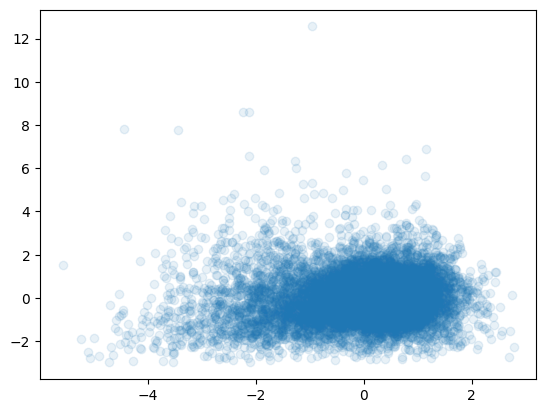

In [10]:
feature_means = cell_covariates.mean(axis=0)
feature_stds = cell_covariates.std(axis=0)
feature_medians = np.median(cell_covariates, axis=0)
feature_mads = np.median(np.abs(cell_covariates - feature_medians), axis=0)

cell_covariates_z_scored = (cell_covariates - feature_means) / feature_stds

plt.scatter(x=cell_covariates_z_scored[:, 0], y=cell_covariates_z_scored[:, 1], alpha=0.1)

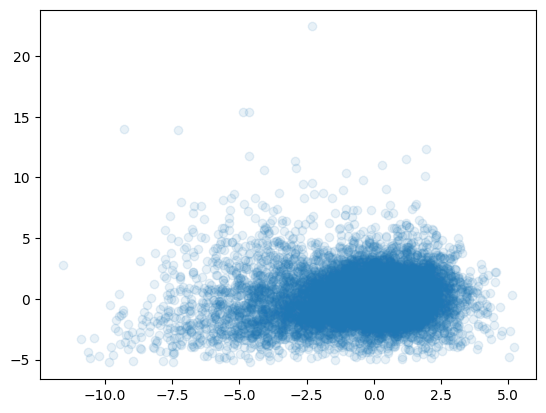

In [11]:
cell_covariates_robust_z_scored = (cell_covariates - feature_medians) / feature_mads
plt.scatter(x=cell_covariates_robust_z_scored[:, 0], y=cell_covariates_robust_z_scored[:, 1], alpha=0.1)

In [12]:
gene_obs = jnp.array(rna_subset.X.toarray()).astype(int)
guide_obs = jnp.array(grna_subset.X).astype(bool)
# guide_obs = guide_obs.at[:, 2:].set(0)
guide_obs.shape

(13052, 2)

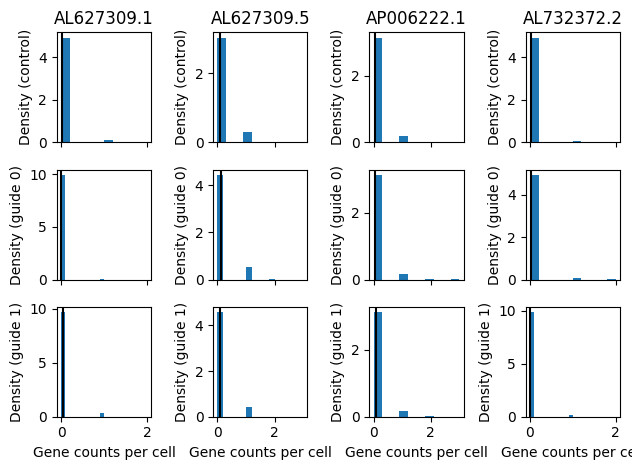

In [13]:
gene_idx = 1

n_plot_genes = min(4, len(genes))

fig, axs = plt.subplots(3, n_plot_genes, sharex="col")


# Control histogram
for gene_idx in range(n_plot_genes):
    max_count = gene_obs[:, gene_idx].max()
    n_bins = min(int(max_count) + 1, 50)
    hist_bins = np.linspace(0, max_count + 1, n_bins)
    hist_bins = None
    control_gene_obs = gene_obs[guide_obs.sum(axis=1) == 0, gene_idx].squeeze()
    axs[0][gene_idx].hist(control_gene_obs, bins=hist_bins, density=True)
    axs[0][gene_idx].axvline(control_gene_obs.mean(), color="black")
    axs[0][gene_idx].set_ylabel("Density (control)")
    axs[0][gene_idx].set_title(genes[gene_idx])

    # Guide histograms
    for i in range(guide_obs.shape[1]):
        guide_gene_obs = gene_obs[guide_obs[:, i].astype(bool), gene_idx].squeeze()
        axs[i + 1][gene_idx].axvline(guide_gene_obs.mean(), color="black")
        # print(np.log2(guide_gene_obs.mean() / control_gene_obs.mean()))
        axs[i + 1][gene_idx].hist(guide_gene_obs, bins=hist_bins, density=True)
        axs[i + 1][gene_idx].set_ylabel(f"Density (guide {i})")
        # axs[i + 1][gene_idx].set_title(f"")

    axs[i + 1][gene_idx].set_xlabel("Gene counts per cell")
plt.tight_layout()
plt.show()

In [14]:
perturbseq_guide = perturbseq_guide_autonormal()
model_args = (gene_obs,)
model_kwargs = {
    "guide_obs": guide_obs,
    "covariates": cell_covariates_robust_z_scored,
    "likelihood": "NegBin",
    "effect_type": "scale",
    "subsample_size": 1000,
}

svi_result = run_svi(
    model_args,
    model_kwargs,
    perturbseq_model,
    perturbseq_guide,
    lr=0.1,
    n_steps=200,
)

  0%|          | 0/1000 [00:00<?, ?it/s]2024-03-21 19:56:24.866762: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.2 = f32[32,16367]{1,0} reduce-window(f32[1000,16367]{1,0} %broadcast.717, f32[] %constant.321), window={size=32x1 stride=32x1 pad=12_12x0_0}, to_apply=%region_49.4332

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2024-03-21 19:56:26.567483: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 2.705771s
Constant folding an instruction is taking > 1s:

  %reduce-window.2 = f32[32,16367]{1,0} reduce-window(f32[1000,16367]{1,0} %broad

KeyboardInterrupt: 

In [15]:
plt.plot(svi_result.losses)

NameError: name 'svi_result' is not defined

In [ ]:
params = svi_result.params
params

{'covariate_weights_auto_loc': Array([[ 0.2301134 ,  0.21664411],
        [-0.09020321, -0.11776778],
        [-0.024041  ,  0.0190435 ]], dtype=float32),
 'covariate_weights_auto_scale': Array([[0.00539403, 0.0040768 ],
        [0.00528471, 0.00431394],
        [0.00392761, 0.00467554]], dtype=float32),
 'dispersion_auto_loc': Array([1.9590108, 1.0083343], dtype=float32),
 'dispersion_auto_scale': Array([0.03053929, 0.02017953], dtype=float32),
 'efficiency_auto_loc': Array([[2.589211 , 2.997519 ],
        [0.7129466, 0.7356398]], dtype=float32),
 'efficiency_auto_scale': Array([[0.5816913 , 0.4340177 ],
        [0.2087301 , 0.14317563]], dtype=float32),
 'log2_fold_change_auto_loc': Array([-0.6499178,  1.3971105], dtype=float32),
 'log2_fold_change_auto_scale': Array([0.02669758, 0.04003486], dtype=float32),
 'mean_auto_loc': Array([2.9912114, 2.0702467], dtype=float32),
 'mean_auto_scale': Array([0.01893342, 0.01019415], dtype=float32)}

In [ ]:
perturbseq_guide.median(params)

{'mean': Array([19.909786 ,  7.9267783], dtype=float32),
 'dispersion': Array([7.092308 , 2.7410314], dtype=float32),
 'efficiency': Array([[0.93016404, 0.9524619 ],
        [0.6710519 , 0.6760417 ]], dtype=float32),
 'log2_fold_change': Array([-0.6499178,  1.3971105], dtype=float32),
 'covariate_weights': Array([[ 0.2301134 ,  0.21664411],
        [-0.09020321, -0.11776778],
        [-0.024041  ,  0.0190435 ]], dtype=float32)}

In [ ]:
unconstrained_locs = {}
for k, v in svi_result.params.items():
    param, param_type = k.split("_auto_")
    if param_type == "loc":
        unconstrained_locs[param] = v

mcmc_result = run_mcmc(model_args, model_kwargs, unconstrained_locs)

warmup:   5%|▍         | 95/2000 [03:02<1:01:04,  1.92s/it, 1023 steps of size 1.70e-03. acc. prob=0.75]


KeyboardInterrupt: 

In [ ]:
mcmc_posterior_samples = mcmc_result.get_samples()
mcmc_posterior_samples.keys()

dict_keys(['covariate_weights', 'dispersion', 'efficiency', 'log2_fold_change', 'mean'])

(1000, 3, 2)
(1000, 2)


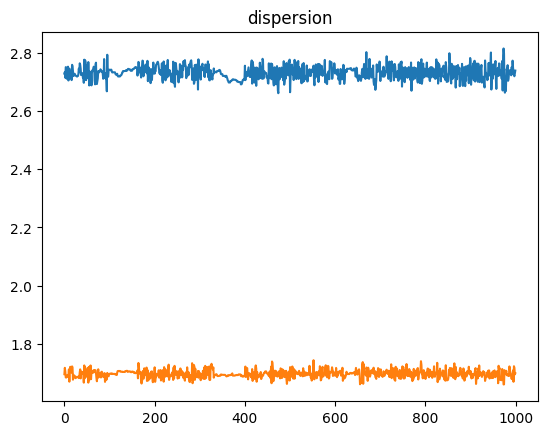

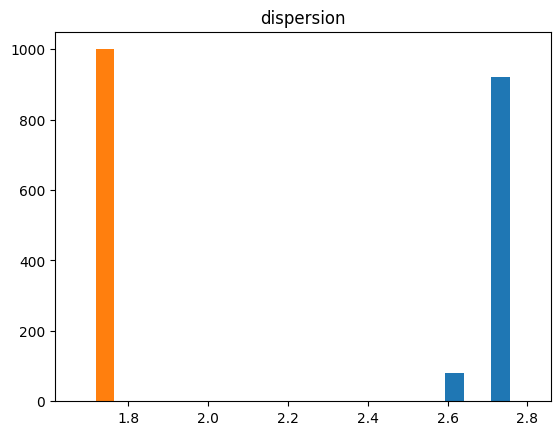

(1000, 2, 2)
(1000, 2)


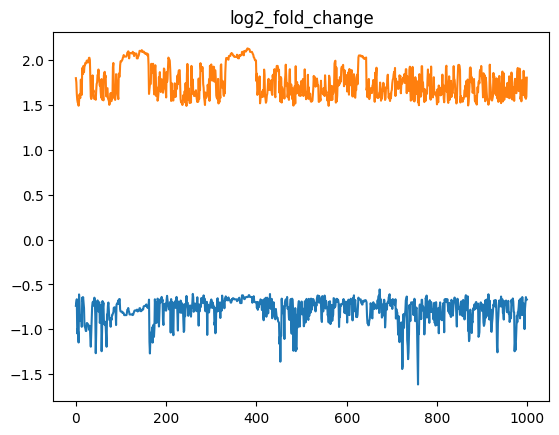

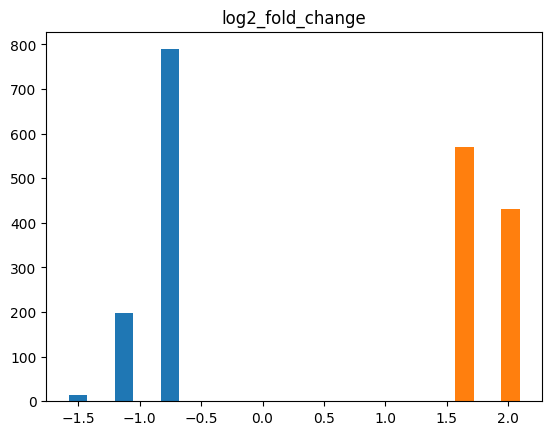

(1000, 2)


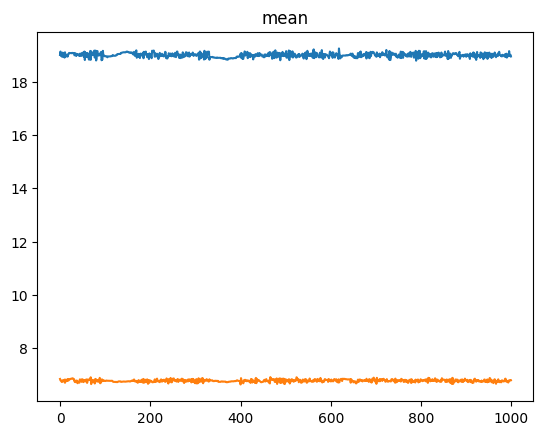

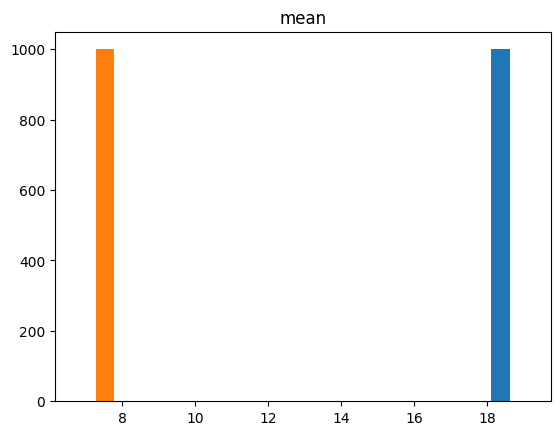

In [ ]:
for k in mcmc_posterior_samples:
    samples_k = mcmc_posterior_samples[k].squeeze()
    print(samples_k.shape)
    if len(samples_k.shape) > 2:
        continue

    plt.plot(samples_k)
    plt.title(k)
    plt.show()

    if len(samples_k.shape) == 2 and samples_k.shape[0] > 1:
        samples_k = samples_k.T

    plt.hist(samples_k)
    plt.title(k)
    plt.show()